In [29]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy 
from scipy import stats
from scipy.stats import (ttest_ind, f_oneway, chi2_contingency,
                         pearsonr, spearmanr, mannwhitneyu)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

C = dict(blue='#3B82F6', green='#10B981', red='#EF4444', orange='#F59E0B',
         purple='#8B5CF6', teal='#14B8A6', pink='#EC4899', dark='#1E293B',
         bg='#F8FAFC', gray='#6B7280')

print("✅ Imports complete")


✅ Imports complete


In [30]:
import pandas as pd

# Load each CSV file from data folder
customer_feedback = pd.read_csv('data/customer_feedback_surveys.csv')
customer_master = pd.read_csv('data/customer_master.csv')
device_info = pd.read_csv('data/device_info.csv')
fraud_alert = pd.read_csv('data/fraud_alert_history.csv')
merchant_info = pd.read_csv('data/merchant_info.csv')
upi_account = pd.read_csv('data/upi_account_details.csv')
upi_transaction = pd.read_csv('data/upi_transaction_history.csv')

In [31]:
# ── Clean ──────────────────────────────────────────────────────
merchant_info     = merchant_info.rename(columns={'risk_score.1': 'risk_category'})
upi_transaction['amount']       = pd.to_numeric(upi_transaction['amount'], errors='coerce')
upi_transaction['fraud_flag']   = upi_transaction['fraud_flag'].astype(str).str.upper() == 'TRUE'
upi_transaction['reversal_flag']= upi_transaction['reversal_flag'].astype(str).str.upper() == 'TRUE'
device_info['is_rooted']        = device_info['is_rooted'].astype(str).str.upper() == 'TRUE'
fraud_alert['resolved']         = fraud_alert['resolved'].astype(str).str.upper() == 'TRUE'
customer_feedback['resolved']   = customer_feedback['resolved'].astype(str).str.upper() == 'TRUE'

print("✅ Tables loaded & cleaned")
for name, df in [('customer_master',customer_master),('upi_transaction',upi_transaction),
                 ('upi_account',upi_account),('device_info',device_info),
                 ('merchant_info',merchant_info),('fraud_alert',fraud_alert),
                 ('customer_feedback',customer_feedback)]:
    print(f"   {name:<25}: {df.shape[0]:>7,} rows  ×  {df.shape[1]:>2} cols")


✅ Tables loaded & cleaned
   customer_master          :  10,000 rows  ×  11 cols
   upi_transaction          : 100,000 rows  ×  15 cols
   upi_account              :  12,000 rows  ×   6 cols
   device_info              :  12,000 rows  ×   9 cols
   merchant_info            :     500 rows  ×   7 cols
   fraud_alert              :   2,000 rows  ×   9 cols
   customer_feedback        :   4,000 rows  ×   9 cols


In [32]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — BUILD RELATIONAL JOINS
# ════════════════════════════════════════════════════════════════
# Master transaction table: txn + customer + merchant + device
txn_full = (
    upi_transaction
    .merge(customer_master[['customer_id','age','gender','region',
                            'is_business_user','risk_score','Age_Group']],
           on='customer_id', how='left')
    .merge(merchant_info[['merchant_id','merchant_name','merchant_type','risk_category']],
           on='merchant_id', how='left')
    .merge(device_info[['device_id','device_os','is_rooted','app_version']],
           on='device_id', how='left')
)

# Fraud alert enriched
fraud_enriched = (
    fraud_alert
    .merge(upi_transaction[['transaction_id','customer_id','amount','status',
                            'fraud_flag','device_type','channel']],
           on='transaction_id', how='left')
    .merge(customer_master[['customer_id','region','Age_Group','risk_score']],
           on='customer_id', how='left')
)

# Feedback enriched
feedback_full = customer_feedback.merge(
    customer_master[['customer_id','age','gender','region','Age_Group','risk_score']],
    on='customer_id', how='left'
)

print(f"\n✅ txn_full shape      : {txn_full.shape}")
print(f"✅ fraud_enriched shape: {fraud_enriched.shape}")
print(f"✅ feedback_full shape : {feedback_full.shape}")



✅ txn_full shape      : (100000, 27)
✅ fraud_enriched shape: (2000, 18)
✅ feedback_full shape : (4000, 14)


In [33]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — DERIVED COLUMNS
# ════════════════════════════════════════════════════════════════

# ── 4A: Transaction Value per Customer ────────────────────────
#    = Total Amount ÷ Number of Transactions per customer
customer_txn_stats = (
    txn_full.groupby('customer_id')
    .agg(total_amount=('amount','sum'),
         txn_count   =('transaction_id','count'))
    .assign(txn_value_per_customer=lambda x: x['total_amount'] / x['txn_count'])
    .reset_index()
)
print("─── Transaction Value per Customer (top 5) ───")
print(customer_txn_stats.sort_values('txn_value_per_customer', ascending=False).head())

# ── 4B: Merchant Fraud Ratio ──────────────────────────────────
#    = Fraud Transactions ÷ Total Transactions by Merchant
merchant_fraud_ratio = (
    txn_full.dropna(subset=['merchant_id'])
    .groupby(['merchant_id','merchant_name','merchant_type'])
    .agg(total_txns =('transaction_id','count'),
         fraud_txns =('fraud_flag','sum'))
    .assign(merchant_fraud_ratio=lambda x: x['fraud_txns'] / x['total_txns'])
    .reset_index()
    .sort_values('merchant_fraud_ratio', ascending=False)
)
print("\n─── Merchant Fraud Ratio (top 5 risky merchants) ───")
print(merchant_fraud_ratio.head())

# ── 4C: Device Fraud Ratio ────────────────────────────────────
#    = Fraud Transactions ÷ Total Transactions by Device
device_fraud_ratio = (
    txn_full.dropna(subset=['device_id'])
    .groupby(['device_id','device_os','device_type'])
    .agg(total_txns=('transaction_id','count'),
         fraud_txns=('fraud_flag','sum'))
    .assign(device_fraud_ratio=lambda x: x['fraud_txns'] / x['total_txns'])
    .reset_index()
    .sort_values('device_fraud_ratio', ascending=False)
)
print("\n─── Device Fraud Ratio (top 5 risky devices) ───")
print(device_fraud_ratio.head())

# ── 4D: Transaction Failure Rate per Customer ─────────────────
#    = Failed Transactions ÷ Total Transactions
customer_failure_rate = (
    txn_full.groupby('customer_id')
    .agg(total      =('transaction_id','count'),
         failed     =('status', lambda x: (x=='failed').sum()))
    .assign(failure_rate=lambda x: x['failed'] / x['total'])
    .reset_index()
    .sort_values('failure_rate', ascending=False)
)
print("\n─── Transaction Failure Rate per Customer (top 5) ───")
print(customer_failure_rate.head())

# ── 4E: Global Failure Rate by Channel ───────────────────────
channel_failure = (
    txn_full.groupby('channel')
    .agg(total  =('transaction_id','count'),
         failed =('status', lambda x: (x=='failed').sum()))
    .assign(failure_rate_pct=lambda x: x['failed']/x['total']*100)
)
print("\n─── Failure Rate by Channel ───")
print(channel_failure)

# ── 4F: Merchant Type Fraud Ratio (aggregated) ────────────────
merchant_type_fraud = (
    txn_full.dropna(subset=['merchant_type'])
    .groupby('merchant_type')
    .agg(total_txns=('transaction_id','count'),
         fraud_txns=('fraud_flag','sum'))
    .assign(fraud_ratio=lambda x: x['fraud_txns']/x['total_txns'],
            fraud_pct  =lambda x: x['fraud_txns']/x['total_txns']*100)
    .sort_values('fraud_ratio', ascending=False)
)
print("\n─── Merchant Type Fraud Ratio ───")
print(merchant_type_fraud)

print("\n✅ All derived columns created")

─── Transaction Value per Customer (top 5) ───
     customer_id  total_amount  txn_count  txn_value_per_customer
3933  cust105555      815.0900          4                203.7725
1939  cust102723      550.7500          4                137.6875
6645  cust109461      506.5000          4                126.6250
3983  cust105631      504.4900          4                126.1225
1652  cust102335      468.7000          4                117.1750

─── Merchant Fraud Ratio (top 5 risky merchants) ───
    merchant_id           merchant_name merchant_type  total_txns  fraud_txns  \
201   merch1201  Garcia, Mann and Sharp       grocery          47           5   
305   merch1305  Ortiz, Gordon and Lutz   electronics          46           4   
358   merch1358           Malone-Willis   electronics          62           5   
80    merch1080              Wilson Inc          food          66           5   
364   merch1364              Taylor LLC     transport          54           4   

     merchant_fr

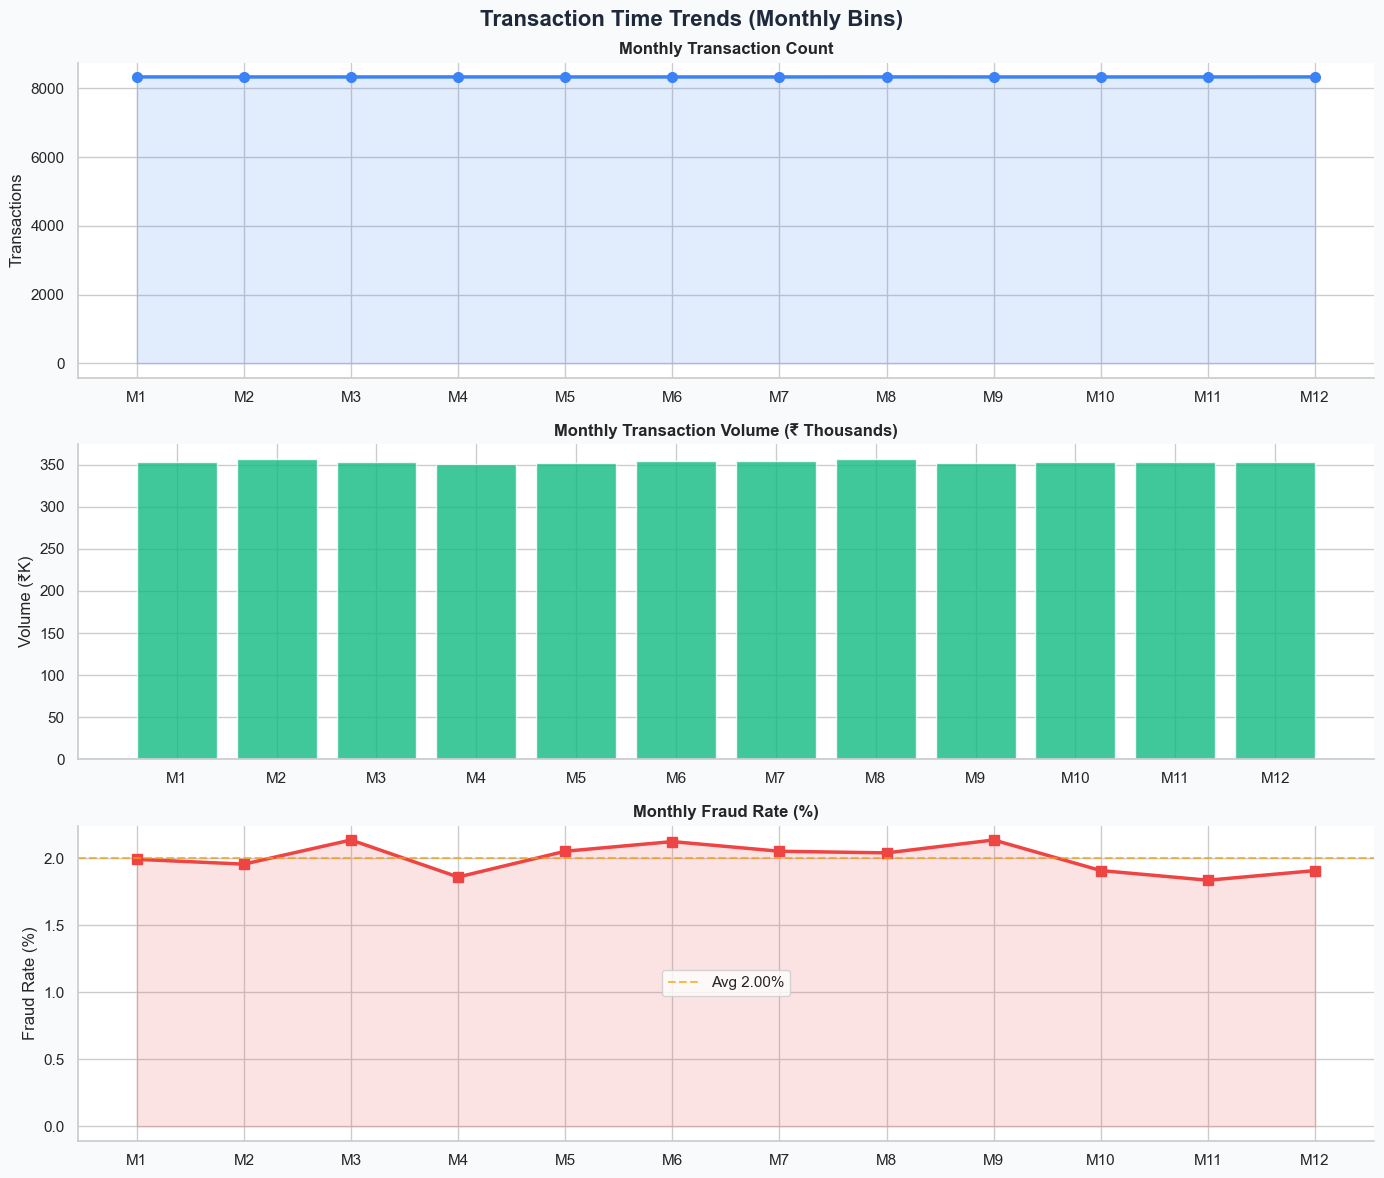

✅ EDA A: Time Trends saved to /mnt/user-data/outputs\eda_A_time_trends.png


In [34]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — EDA FIGURE A: TIME TRENDS (FIXED)
# ════════════════════════════════════════════════════════════════
import os
import matplotlib.pyplot as plt
import pandas as pd

# Note: Ensure txn_full and C dictionary are defined in previous cells

# 1. DATA PREPARATION
# Extract sequence number from transaction_id
# Ensure column is string before extracting to avoid errors
txn_full['txn_seq'] = txn_full['transaction_id'].astype(str).str.extract(r'(\d+)').astype(float).astype('Int64')

# Create monthly bins
txn_full['month_bin'] = pd.cut(txn_full['txn_seq'], bins=12,
                                labels=[f'M{i+1}' for i in range(12)])

# Group by month_bin (observed=True ensures only existing categories are used)
monthly = txn_full.groupby('month_bin', observed=True).agg(
    txn_count  =('transaction_id','count'),
    total_vol  =('amount','sum'),
    fraud_count=('fraud_flag','sum')
).reset_index()

# Calculate fraud rate safely
monthly['fraud_rate'] = monthly.apply(lambda x: (x['fraud_count'] / x['txn_count'] * 100) if x['txn_count'] > 0 else 0, axis=1)

# 2. PLOTTING SETUP
# Define output directory and CREATE IT if it doesn't exist (Fixes FileNotFoundError)
output_dir = '/mnt/user-data/outputs' 
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Transaction Time Trends (Monthly Bins)', fontsize=16,
             fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

# Use numerical indices for X-axis to ensure alignment across plot, bar, and fill_between
x_indices = range(len(monthly))

# --- Plot 1: Volume ---
axes[0].plot(x_indices, monthly['txn_count'],
             marker='o', color=C['blue'], linewidth=2.5, markersize=7)
axes[0].fill_between(x_indices, monthly['txn_count'],
                      alpha=0.15, color=C['blue'])
axes[0].set_title('Monthly Transaction Count', fontweight='bold')
axes[0].set_ylabel('Transactions')
axes[0].set_xticks(x_indices)
axes[0].set_xticklabels(monthly['month_bin'])
axes[0].spines[['top','right']].set_visible(False)

# --- Plot 2: Amount ---
axes[1].bar(x_indices, monthly['total_vol']/1000,
            color=C['green'], alpha=0.8, edgecolor='white')
axes[1].set_title('Monthly Transaction Volume (₹ Thousands)', fontweight='bold')
axes[1].set_ylabel('Volume (₹K)')
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(monthly['month_bin'])
axes[1].spines[['top','right']].set_visible(False)

# --- Plot 3: Fraud Rate ---
axes[2].plot(x_indices, monthly['fraud_rate'],
             marker='s', color=C['red'], linewidth=2.5, markersize=7)
avg_fraud = monthly['fraud_rate'].mean()
axes[2].axhline(avg_fraud, color=C['orange'],
                linestyle='--', alpha=0.7, label=f"Avg {avg_fraud:.2f}%")
axes[2].fill_between(x_indices, monthly['fraud_rate'],
                      alpha=0.15, color=C['red'])
axes[2].set_title('Monthly Fraud Rate (%)', fontweight='bold')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xticks(x_indices)
axes[2].set_xticklabels(monthly['month_bin'])
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()

# 3. SAVE FIGURE
# Use os.path.join to construct the path safely
save_path = os.path.join(output_dir, 'eda_A_time_trends.png')
plt.savefig(save_path, dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print(f"✅ EDA A: Time Trends saved to {save_path}")

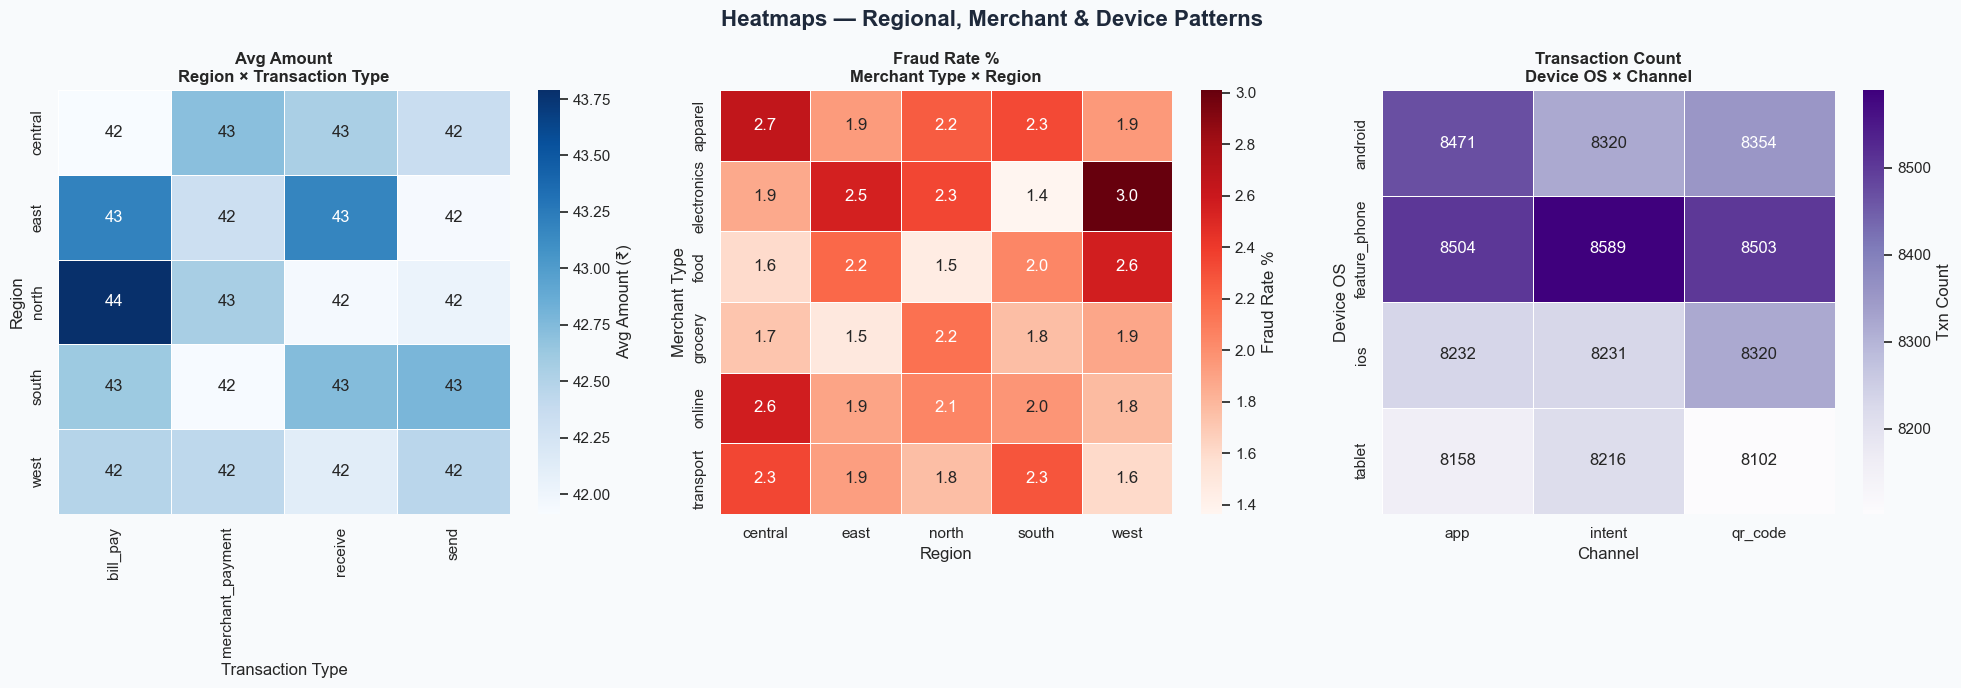

✅ EDA B: Heatmaps saved


In [35]:

# Define Output Directory and CREATE IT if it doesn't exist
OUTPUT_DIR = '/mnt/user-data/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ensure color dictionary C exists (from previous cells)
# If C is not defined, this will raise a NameError, but assuming it exists from Cell 1/2
# Example fallback if needed:
# if 'C' not in globals(): C = {'bg':'white', 'dark':'black', 'blue':'#1f77b4', 'red':'#d62728', 'green':'#2ca02c', 'orange':'#ff7f0e', 'teal':'#17becf', 'purple':'#9467bd', 'gray':'#7f7f7f'}

# ════════════════════════════════════════════════════════════════
# CELL 6 — EDA FIGURE B: HEATMAPS
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Heatmaps — Regional, Merchant & Device Patterns',
             fontsize=16, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

# ── B1: Region × Transaction Type — Avg Amount ────────────────
hm1 = txn_full.groupby(['region','transaction_type'], observed=True)['amount'].mean().unstack(fill_value=0)
sns.heatmap(hm1, ax=axes[0], annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label':'Avg Amount (₹)'})
axes[0].set_title('Avg Amount\nRegion × Transaction Type', fontweight='bold')
axes[0].set_xlabel('Transaction Type'); axes[0].set_ylabel('Region')

# ── B2: Merchant Type × Region — Fraud Rate % ─────────────────
hm2 = (txn_full.dropna(subset=['merchant_type'])
        .groupby(['merchant_type','region'], observed=True)
        .apply(lambda x: x['fraud_flag'].mean()*100)
        .unstack(fill_value=0))
sns.heatmap(hm2, ax=axes[1], annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label':'Fraud Rate %'})
axes[1].set_title('Fraud Rate %\nMerchant Type × Region', fontweight='bold')
axes[1].set_xlabel('Region'); axes[1].set_ylabel('Merchant Type')

# ── B3: Device OS × Channel — Transaction Count ───────────────
hm3 = (txn_full.dropna(subset=['device_os'])
        .groupby(['device_os','channel'], observed=True)['transaction_id'].count()
        .unstack(fill_value=0))
sns.heatmap(hm3, ax=axes[2], annot=True, fmt='d', cmap='Purples',
            linewidths=0.5, cbar_kws={'label':'Txn Count'})
axes[2].set_title('Transaction Count\nDevice OS × Channel', fontweight='bold')
axes[2].set_xlabel('Channel'); axes[2].set_ylabel('Device OS')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_B_heatmaps.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ EDA B: Heatmaps saved")



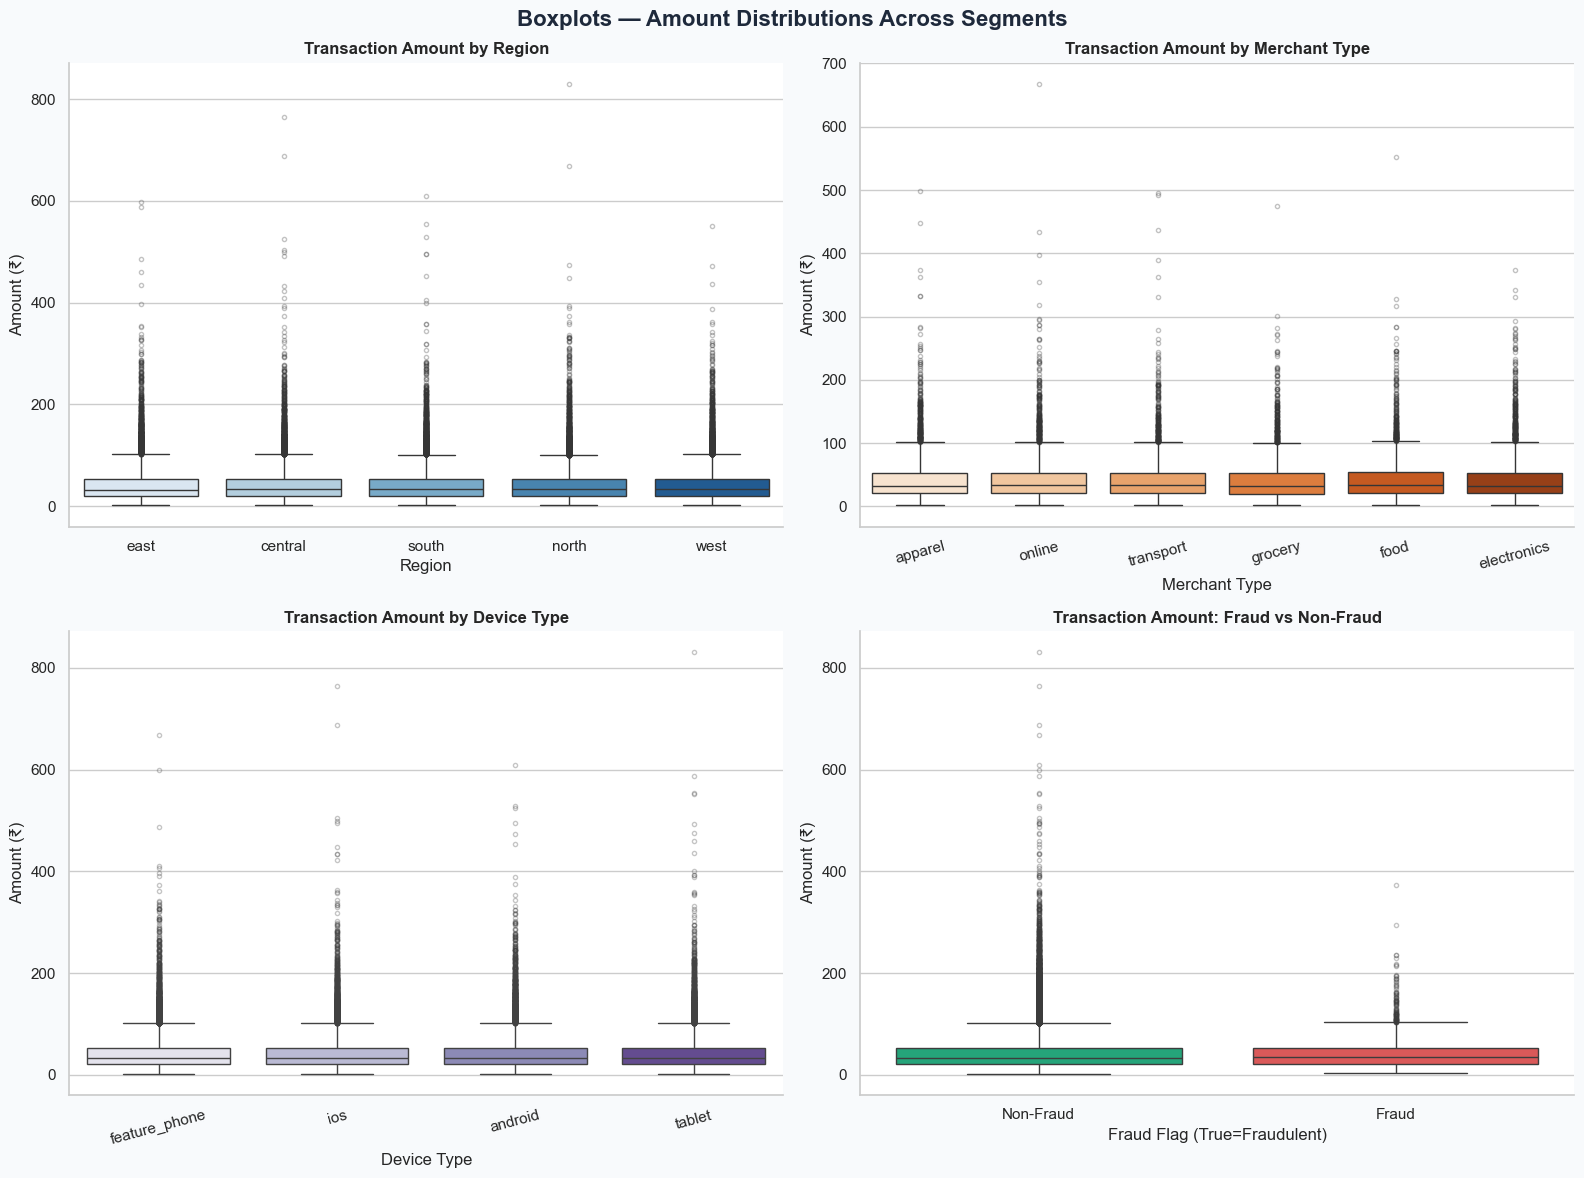

✅ EDA C: Boxplots saved


In [43]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — EDA FIGURE C: BOXPLOTS (FIXED)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Boxplots — Amount Distributions Across Segments',
             fontsize=16, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

# ── C1: Amount by Region ──────────────────────────────────────
sns.boxplot(data=txn_full, x='region', y='amount', ax=axes[0,0],
            palette='Blues', flierprops=dict(marker='.', alpha=0.3))
axes[0,0].set_title('Transaction Amount by Region', fontweight='bold')
axes[0,0].set_xlabel('Region'); axes[0,0].set_ylabel('Amount (₹)')
axes[0,0].spines[['top','right']].set_visible(False)

# ── C2: Amount by Merchant Type ───────────────────────────────
sns.boxplot(data=txn_full.dropna(subset=['merchant_type']),
            x='merchant_type', y='amount', ax=axes[0,1],
            palette='Oranges', flierprops=dict(marker='.', alpha=0.3))
axes[0,1].set_title('Transaction Amount by Merchant Type', fontweight='bold')
axes[0,1].set_xlabel('Merchant Type'); axes[0,1].set_ylabel('Amount (₹)')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].spines[['top','right']].set_visible(False)

# ── C3: Amount by Device Type ─────────────────────────────────
sns.boxplot(data=txn_full, x='device_type', y='amount', ax=axes[1,0],
            palette='Purples', flierprops=dict(marker='.', alpha=0.3))
axes[1,0].set_title('Transaction Amount by Device Type', fontweight='bold')
axes[1,0].set_xlabel('Device Type'); axes[1,0].set_ylabel('Amount (₹)')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].spines[['top','right']].set_visible(False)

# ── C4: Amount by Fraud Flag ──────────────────────────────────
# FIX: Convert fraud_flag to string to ensure palette keys match exactly
# This avoids conflicts between boolean (True/False) and int (0/1) keys
txn_full['fraud_flag_str'] = txn_full['fraud_flag'].astype(str)

sns.boxplot(data=txn_full, x='fraud_flag_str', y='amount', ax=axes[1,1],
            palette={'True': C['red'], 'False': C['green'], '1': C['red'], '0': C['green']},
            flierprops=dict(marker='.', alpha=0.3))
axes[1,1].set_title('Transaction Amount: Fraud vs Non-Fraud', fontweight='bold')
axes[1,1].set_xlabel('Fraud Flag (True=Fraudulent)'); axes[1,1].set_ylabel('Amount (₹)')
axes[1,1].set_xticklabels(['Non-Fraud', 'Fraud'])  # Cleaner labels
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_C_boxplots.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ EDA C: Boxplots saved")


════════════════════════════════════════════════════════════
  GROUPED STATISTICS SUMMARY
════════════════════════════════════════════════════════════

── Amount Statistics by Region ──
           mean  median     std  count  fraud_rate_%  failure_rate_%
region                                                              
central 42.4900 33.3400 34.5400  19677        1.9410          5.7020
east    42.5300 32.9100 34.3100  20078        2.0020          5.8620
north   42.2100 33.0700 34.1800  20787        1.9440          6.0130
south   42.5400 33.1400 34.2400  19372        2.0290          5.7820
west    42.3300 33.0500 33.6700  20086        2.0860          5.9840

── Amount Statistics by Merchant Type ──
                 mean  median     std  count  fraud_rate_%
merchant_type                                             
apparel       42.1000 32.8200 33.7700   5986        2.2220
electronics   42.6600 33.1200 34.3200   5485        2.2420
food          42.3900 33.4600 33.1300   4811        

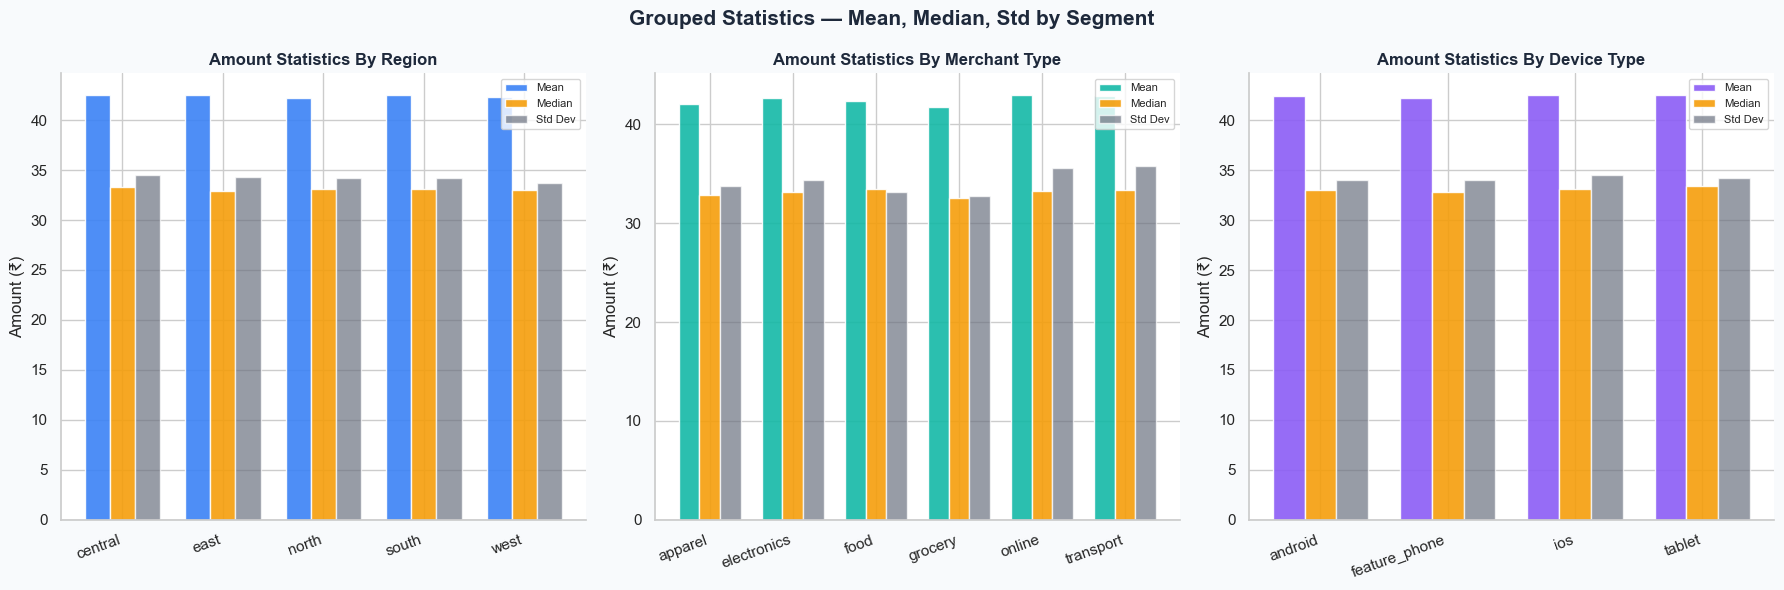

✅ EDA D: Grouped Stats saved


In [36]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — EDA FIGURE D: GROUPED STATISTICS
# ════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  GROUPED STATISTICS SUMMARY")
print("═"*60)

# ── D1: By Region ─────────────────────────────────────────────
region_stats = txn_full.groupby('region', observed=True)['amount'].agg(
    ['mean','median','std','count']).round(2)
region_stats['fraud_rate_%'] = (txn_full.groupby('region', observed=True)['fraud_flag']
                                  .mean() * 100).round(3)
region_stats['failure_rate_%'] = (txn_full.groupby('region', observed=True)['status']
                                    .apply(lambda x: (x=='failed').mean()*100)).round(3)
print("\n── Amount Statistics by Region ──")
print(region_stats.to_string())

# ── D2: By Merchant Type ──────────────────────────────────────
merchant_stats = (txn_full.dropna(subset=['merchant_type'])
                   .groupby('merchant_type', observed=True)['amount']
                   .agg(['mean','median','std','count']).round(2))
merchant_stats['fraud_rate_%'] = (txn_full.dropna(subset=['merchant_type'])
                                    .groupby('merchant_type', observed=True)['fraud_flag']
                                    .mean() * 100).round(3)
print("\n── Amount Statistics by Merchant Type ──")
print(merchant_stats.to_string())

# ── D3: By Device Type ────────────────────────────────────────
device_stats = txn_full.groupby('device_type', observed=True)['amount'].agg(
    ['mean','median','std','count']).round(2)
device_stats['fraud_rate_%'] = (txn_full.groupby('device_type', observed=True)['fraud_flag']
                                  .mean()*100).round(3)
print("\n── Amount Statistics by Device Type ──")
print(device_stats.to_string())

# ── D4: High-Activity Segments ────────────────────────────────
print("\n── Top 5 High-Activity Customers (by txn count) ──")
high_activity = (txn_full.groupby('customer_id', observed=True)
                  .agg(txn_count=('transaction_id','count'),
                       total_spent=('amount','sum'),
                       fraud_count=('fraud_flag','sum'))
                  .sort_values('txn_count', ascending=False).head(5))
print(high_activity.to_string())

print("\n── Top 5 High-Risk Customers (by fraud count) ──")
high_risk = (txn_full.groupby('customer_id', observed=True)
              .agg(fraud_count=('fraud_flag','sum'),
                   total_txns=('transaction_id','count'),
                   risk_score=('risk_score','first'))
              .assign(fraud_rate=lambda x: x['fraud_count']/x['total_txns'])
              .sort_values('fraud_count', ascending=False).head(5))
print(high_risk.to_string())

# ── D5: Plot grouped stats ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Grouped Statistics — Mean, Median, Std by Segment',
             fontsize=15, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

# Ensure we don't plot if dataframes are empty
plot_data = [
    ('region', region_stats, 'By Region', C['blue']),
    ('merchant_type', merchant_stats, 'By Merchant Type', C['teal']),
    ('device_type', device_stats, 'By Device Type', C['purple'])
]

for ax, (grp, df, title, color) in zip(axes, plot_data):
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, ha='center')
        continue
    x = range(len(df))
    ax.bar([i-0.25 for i in x], df['mean'],   width=0.25, label='Mean',   color=color, alpha=0.9)
    ax.bar([i      for i in x], df['median'], width=0.25, label='Median', color=C['orange'], alpha=0.9)
    ax.bar([i+0.25 for i in x], df['std'],    width=0.25, label='Std Dev',color=C['gray'], alpha=0.7)
    ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=20, ha='right')
    ax.set_title(f'Amount Statistics {title}', fontweight='bold', color=C['dark'])
    ax.set_ylabel('Amount (₹)'); ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_D_grouped_stats.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ EDA D: Grouped Stats saved")



In [37]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — STATISTICAL TESTS HELPER
# ════════════════════════════════════════════════════════════════
def print_test_header(title):
    print(f"\n{'═'*60}")
    print(f"  {title}")
    print(f"{'═'*60}")

def interpret_pvalue(p, alpha=0.05):
    if p < 0.001:  return f"p={p:.4f} *** HIGHLY SIGNIFICANT (< 0.001)"
    elif p < 0.01: return f"p={p:.4f} **  SIGNIFICANT (< 0.01)"
    elif p < 0.05: return f"p={p:.4f} *   SIGNIFICANT (< 0.05)"
    else:          return f"p={p:.4f}     NOT significant (≥ 0.05)"




════════════════════════════════════════════════════════════
  T-TEST: Avg Transaction Amount — Android vs iOS
════════════════════════════════════════════════════════════

  Group 1 — Android : n=25,145, mean=₹42.38, std=₹34.04
  Group 2 — iOS     : n=24,783, mean=₹42.54, std=₹34.50

  Welch's t-statistic : -0.5408
  p=0.5887     NOT significant (≥ 0.05)

  95% CI for (Android − iOS) mean difference: [₹-0.77, ₹0.44]

  Interpretation:
  ❌ Fail to reject H0: No significant difference found.

  Assumptions: Independence ✓ | Normality approximated by CLT (large n) ✓


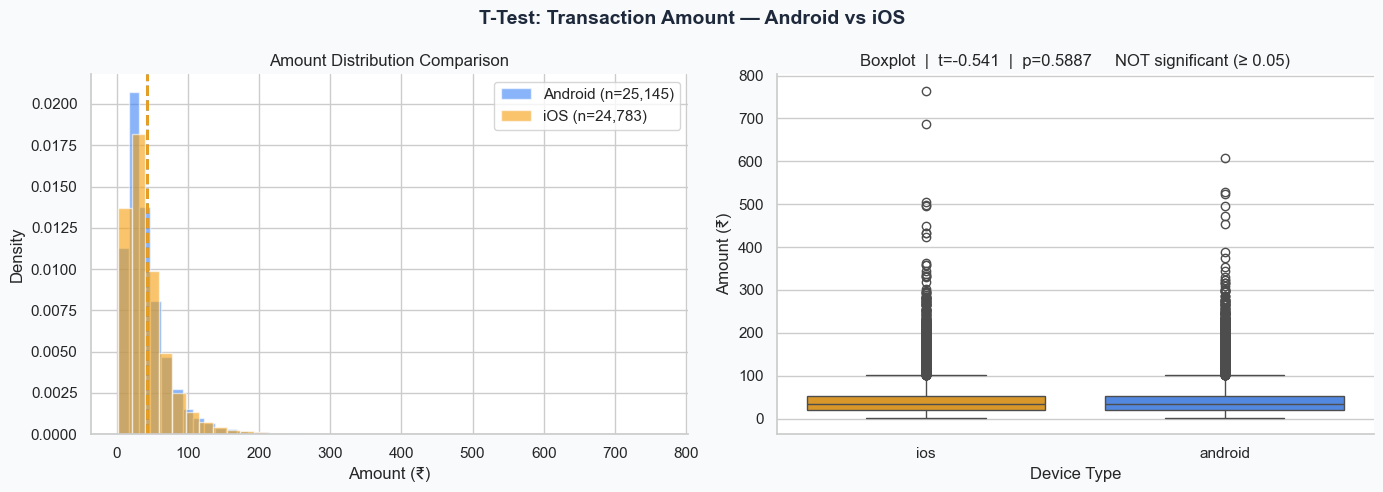

✅ T-Test chart saved


In [38]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — STAT TEST 1: T-TEST
# ════════════════════════════════════════════════════════════════
print_test_header("T-TEST: Avg Transaction Amount — Android vs iOS")

android_amounts = txn_full[txn_full['device_type']=='android']['amount'].dropna()
ios_amounts     = txn_full[txn_full['device_type']=='ios']['amount'].dropna()

# Check if groups have data
if len(android_amounts) > 1 and len(ios_amounts) > 1:
    t_stat, p_val = ttest_ind(android_amounts, ios_amounts, equal_var=False)  # Welch's t-test
    
    print(f"\n  Group 1 — Android : n={len(android_amounts):,}, mean=₹{android_amounts.mean():.2f}, "
          f"std=₹{android_amounts.std():.2f}")
    print(f"  Group 2 — iOS     : n={len(ios_amounts):,}, mean=₹{ios_amounts.mean():.2f}, "
          f"std=₹{ios_amounts.std():.2f}")
    print(f"\n  Welch's t-statistic : {t_stat:.4f}")
    print(f"  {interpret_pvalue(p_val)}")
    
    # Confidence interval (95%) for difference in means
    diff_mean = android_amounts.mean() - ios_amounts.mean()
    se = np.sqrt(android_amounts.var()/len(android_amounts) + ios_amounts.var()/len(ios_amounts))
    ci_low  = diff_mean - 1.96*se
    ci_high = diff_mean + 1.96*se
    print(f"\n  95% CI for (Android − iOS) mean difference: [₹{ci_low:.2f}, ₹{ci_high:.2f}]")
    print(f"\n  Interpretation:")
    if p_val < 0.05:
        print(f"  ✅ Reject H0: Significant difference in avg transaction amounts")
        print(f"     between Android (₹{android_amounts.mean():.2f}) and iOS (₹{ios_amounts.mean():.2f}) users.")
    else:
        print(f"  ❌ Fail to reject H0: No significant difference found.")
    print(f"\n  Assumptions: Independence ✓ | Normality approximated by CLT (large n) ✓")
else:
    print("⚠️ Insufficient data for T-Test (need >1 sample per group)")
    t_stat, p_val = 0, 1.0 # Default values to prevent errors in plotting later

# ── T-Test Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('T-Test: Transaction Amount — Android vs iOS',
             fontsize=14, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

if len(android_amounts) > 0:
    axes[0].hist(android_amounts, bins=40, alpha=0.6, color=C['blue'],
                 label=f'Android (n={len(android_amounts):,})', density=True)
if len(ios_amounts) > 0:
    axes[0].hist(ios_amounts, bins=40, alpha=0.6, color=C['orange'],
                 label=f'iOS (n={len(ios_amounts):,})', density=True)

if len(android_amounts) > 0: axes[0].axvline(android_amounts.mean(), color=C['blue'], linestyle='--', linewidth=2)
if len(ios_amounts) > 0: axes[0].axvline(ios_amounts.mean(), color=C['orange'], linestyle='--', linewidth=2)

axes[0].set_title('Amount Distribution Comparison')
axes[0].set_xlabel('Amount (₹)'); axes[0].set_ylabel('Density')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

sns.boxplot(data=txn_full[txn_full['device_type'].isin(['android','ios'])],
            x='device_type', y='amount', ax=axes[1],
            palette={'android': C['blue'], 'ios': C['orange']})
axes[1].set_title(f'Boxplot  |  t={t_stat:.3f}  |  {interpret_pvalue(p_val)}')
axes[1].set_xlabel('Device Type'); axes[1].set_ylabel('Amount (₹)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_1_ttest.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ T-Test chart saved")




════════════════════════════════════════════════════════════
  ONE-WAY ANOVA: Fraud Rate Variability by Merchant Type
════════════════════════════════════════════════════════════

  Groups tested: ['apparel', 'online', 'transport', 'grocery', 'food', 'electronics']

  Per-group fraud rates:
    apparel        : mean=2.222%  std=14.739%  n=5,986
    online         : mean=2.242%  std=14.806%  n=5,485
    transport      : mean=1.975%  std=13.913%  n=4,811
    grocery        : mean=1.805%  std=13.313%  n=4,488
    food           : mean=2.050%  std=14.170%  n=5,171
    electronics    : mean=1.972%  std=13.905%  n=4,208

  F-statistic : 0.6935
  p=0.6283     NOT significant (≥ 0.05)

  Interpretation:
  ❌ Fail to reject H0: No significant difference in fraud rates.

  Assumptions: Independence ✓ | Normal distribution within groups (CLT) ✓
  Limitation : ANOVA tells us 'something is different' but not which pair.
               Use post-hoc tests (Tukey HSD) to identify specific pairs.

── A

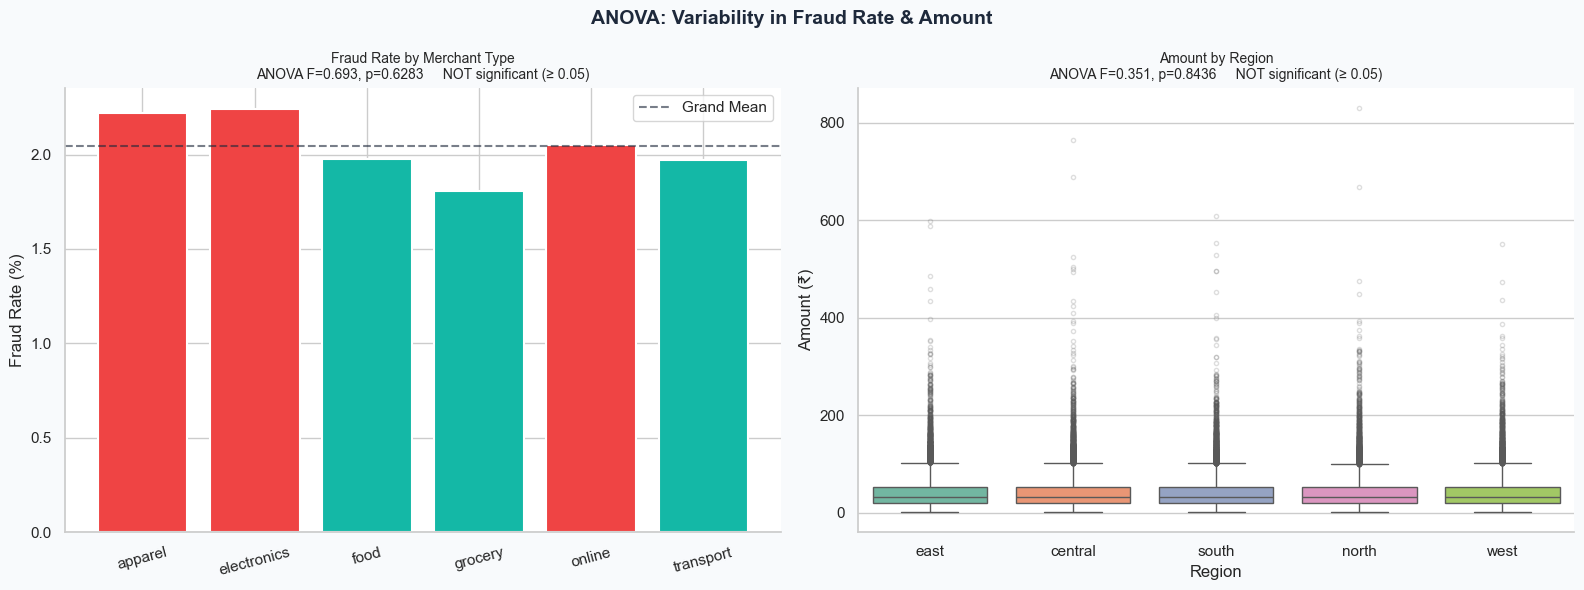

✅ ANOVA chart saved


In [39]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — STAT TEST 2: ONE-WAY ANOVA
# ════════════════════════════════════════════════════════════════
print_test_header("ONE-WAY ANOVA: Fraud Rate Variability by Merchant Type")

merchant_groups = [
    group['fraud_flag'].astype(float).values
    for _, group in txn_full.dropna(subset=['merchant_type']).groupby('merchant_type', observed=True)
]
group_names = txn_full.dropna(subset=['merchant_type'])['merchant_type'].unique()

if len(merchant_groups) > 1 and all(len(g) > 0 for g in merchant_groups):
    f_stat, p_val_anova = f_oneway(*merchant_groups)
    
    print(f"\n  Groups tested: {list(group_names)}")
    print(f"\n  Per-group fraud rates:")
    for name, grp in zip(group_names, merchant_groups):
        print(f"    {name:<15}: mean={np.mean(grp)*100:.3f}%  std={np.std(grp)*100:.3f}%  n={len(grp):,}")
    print(f"\n  F-statistic : {f_stat:.4f}")
    print(f"  {interpret_pvalue(p_val_anova)}")
    print(f"\n  Interpretation:")
    if p_val_anova < 0.05:
        print(f"  ✅ Reject H0: Fraud rates differ significantly across merchant types.")
        print(f"     At least one merchant type has a statistically different fraud rate.")
    else:
        print(f"  ❌ Fail to reject H0: No significant difference in fraud rates.")
    print(f"\n  Assumptions: Independence ✓ | Normal distribution within groups (CLT) ✓")
    print(f"  Limitation : ANOVA tells us 'something is different' but not which pair.")
    print(f"               Use post-hoc tests (Tukey HSD) to identify specific pairs.")
else:
    print("⚠️ Insufficient groups for ANOVA")
    f_stat, p_val_anova = 0, 1.0

# ── ANOVA — Region ────────────────────────────────────────────
print("\n── ANOVA: Transaction Amount Variability by Region ──")
region_groups = [group['amount'].dropna().values
                 for _, group in txn_full.groupby('region', observed=True)]
if len(region_groups) > 1:
    f2, p2 = f_oneway(*region_groups)
    print(f"  F-statistic: {f2:.4f}  |  {interpret_pvalue(p2)}")
else:
    f2, p2 = 0, 1.0

# ── ANOVA Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANOVA: Variability in Fraud Rate & Amount',
             fontsize=14, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

merch_fraud_plot = (txn_full.dropna(subset=['merchant_type'])
                    .groupby('merchant_type', observed=True)['fraud_flag']
                    .mean().reset_index())
merch_fraud_plot.columns = ['merchant_type','fraud_rate']
merch_fraud_plot['fraud_rate'] *= 100

if not merch_fraud_plot.empty:
    colors_bar = [C['red'] if v > merch_fraud_plot['fraud_rate'].mean()
                  else C['teal'] for v in merch_fraud_plot['fraud_rate']]
    axes[0].bar(merch_fraud_plot['merchant_type'], merch_fraud_plot['fraud_rate'],
                color=colors_bar, edgecolor='white', linewidth=1.5)
    axes[0].axhline(merch_fraud_plot['fraud_rate'].mean(), color=C['dark'],
                    linestyle='--', alpha=0.6, label='Grand Mean')
    axes[0].set_title(f'Fraud Rate by Merchant Type\nANOVA F={f_stat:.3f}, {interpret_pvalue(p_val_anova)}',
                      fontsize=10)
    axes[0].set_ylabel('Fraud Rate (%)'); axes[0].legend()
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].spines[['top','right']].set_visible(False)

sns.boxplot(data=txn_full, x='region', y='amount', ax=axes[1],
            palette='Set2', flierprops=dict(marker='.', alpha=0.2))
axes[1].set_title(f'Amount by Region\nANOVA F={f2:.3f}, {interpret_pvalue(p2)}', fontsize=10)
axes[1].set_xlabel('Region'); axes[1].set_ylabel('Amount (₹)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_2_anova.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ ANOVA chart saved")




════════════════════════════════════════════════════════════
  CHI-SQUARE: Association — Fraud Flag × Channel
════════════════════════════════════════════════════════════

  Contingency Table — Fraud × Channel:
channel       app  intent  qr_code     All
fraud_flag                                
False       32692   32727    32581   98000
True          673     629      698    2000
All         33365   33356    33279  100000

  Chi² statistic : 3.8837
  Degrees of freedom: 2
  p=0.1434     NOT significant (≥ 0.05)
  ❌ Fail to reject H0: No significant association found.

── CHI-SQUARE: Transaction Status × Device Type ──
  Chi² = 5.9344  |  df = 6  |  p=0.4306     NOT significant (≥ 0.05)

  Assumptions: Expected cell frequency ≥ 5 ✓ (large n)
  Limitation : Chi-square detects association but NOT direction or strength.
               Use Cramér's V for effect size.
  Cramér's V (effect size): 0.0054  (Weak)


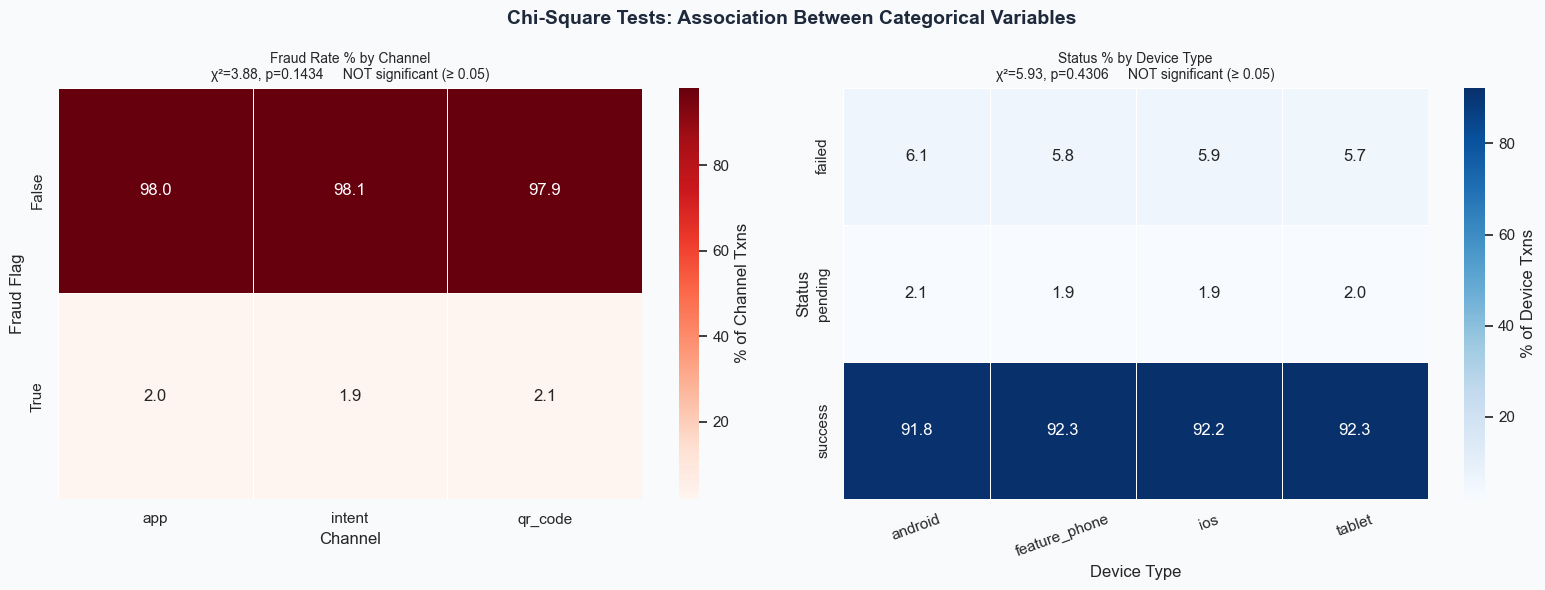

✅ Chi-Square chart saved


In [40]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — STAT TEST 3: CHI-SQUARE
# ════════════════════════════════════════════════════════════════
print_test_header("CHI-SQUARE: Association — Fraud Flag × Channel")

# Contingency table
ct_fraud_channel = pd.crosstab(
    txn_full['fraud_flag'],
    txn_full['channel'],
    margins=True
)
print("\n  Contingency Table — Fraud × Channel:")
print(ct_fraud_channel.to_string())

ct_clean = pd.crosstab(txn_full['fraud_flag'], txn_full['channel'])
if ct_clean.shape[0] > 1 and ct_clean.shape[1] > 1:
    chi2, p_chi, dof, expected = chi2_contingency(ct_clean)
    print(f"\n  Chi² statistic : {chi2:.4f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  {interpret_pvalue(p_chi)}")
    if p_chi < 0.05:
        print(f"  ✅ Reject H0: Fraud flag and channel are NOT independent.")
        print(f"     Transaction channel is significantly associated with fraud.")
    else:
        print(f"  ❌ Fail to reject H0: No significant association found.")
else:
    print("⚠️ Insufficient categories for Chi-Square")
    chi2, p_chi = 0, 1.0

# ── Chi-Square: Status × Device Type ─────────────────────────
print("\n── CHI-SQUARE: Transaction Status × Device Type ──")
ct2 = pd.crosstab(txn_full['status'], txn_full['device_type'])
if ct2.shape[0] > 1 and ct2.shape[1] > 1:
    chi2b, p_b, dof_b, _ = chi2_contingency(ct2)
    print(f"  Chi² = {chi2b:.4f}  |  df = {dof_b}  |  {interpret_pvalue(p_b)}")
    print(f"\n  Assumptions: Expected cell frequency ≥ 5 ✓ (large n)")
    print(f"  Limitation : Chi-square detects association but NOT direction or strength.")
    print(f"               Use Cramér's V for effect size.")
    
    # Cramér's V effect size
    def cramers_v(chi2_val, n, r, c):
        return np.sqrt(chi2_val / (n * (min(r,c) - 1)))
    n = ct2.values.sum()
    v = cramers_v(chi2b, n, ct2.shape[0], ct2.shape[1])
    print(f"  Cramér's V (effect size): {v:.4f}  "
          f"({'Weak' if v < 0.1 else 'Moderate' if v < 0.3 else 'Strong'})")
else:
    chi2b, p_b = 0, 1.0

# ── Chi-Square Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Chi-Square Tests: Association Between Categorical Variables",
             fontsize=14, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

# Fraud × Channel normalized heatmap
ct_norm = pd.crosstab(txn_full['fraud_flag'], txn_full['channel'], normalize='columns') * 100
sns.heatmap(ct_norm, ax=axes[0], annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label':'% of Channel Txns'})
axes[0].set_title(f'Fraud Rate % by Channel\nχ²={chi2:.2f}, {interpret_pvalue(p_chi)}',
                  fontsize=10)
axes[0].set_xlabel('Channel'); axes[0].set_ylabel('Fraud Flag')

# Status × Device heatmap
ct2_norm = pd.crosstab(txn_full['status'], txn_full['device_type'], normalize='columns') * 100
sns.heatmap(ct2_norm, ax=axes[1], annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label':'% of Device Txns'})
axes[1].set_title(f'Status % by Device Type\nχ²={chi2b:.2f}, {interpret_pvalue(p_b)}',
                  fontsize=10)
axes[1].set_xlabel('Device Type'); axes[1].set_ylabel('Status')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_3_chisquare.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ Chi-Square chart saved")




════════════════════════════════════════════════════════════
  CORRELATION: risk_score vs Transaction & Fraud Behavior
════════════════════════════════════════════════════════════

  n = 7,032 customers

  Variable                   Pearson r      p-value   Spearman ρ      p-value
  ──────────────────────────────────────────────────────────────────────
  txn_count                    -0.0162       0.1731        -0.0082       0.4894
  avg_amount                   +0.0034       0.7757        -0.0048       0.6896
  fraud_rate                   +0.0017       0.8842        -0.0095       0.4281
  failure_rate                 +0.0033       0.7821        +0.0002       0.9897

  *** p<0.001  ** p<0.01  * p<0.05

  Interpretation:
  - Pearson r measures LINEAR correlation (sensitive to outliers)
  - Spearman ρ measures RANK correlation (robust, non-parametric)
  - |r| < 0.1: Negligible | 0.1–0.3: Weak | 0.3–0.5: Moderate | >0.5: Strong


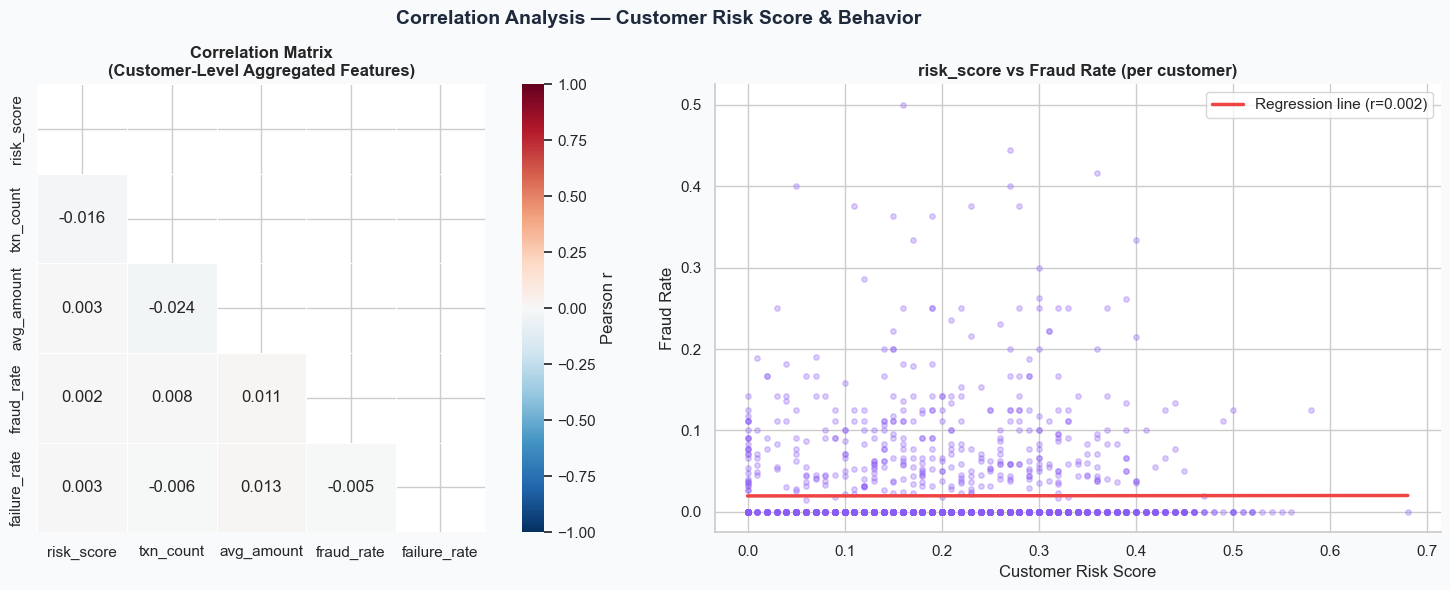

✅ Correlation chart saved


In [41]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — STAT TEST 4: CORRELATION ANALYSIS
# ════════════════════════════════════════════════════════════════
print_test_header("CORRELATION: risk_score vs Transaction & Fraud Behavior")

# Customer-level aggregation
cust_corr = txn_full.groupby('customer_id', observed=True).agg(
    risk_score    =('risk_score','first'),
    txn_count     =('transaction_id','count'),
    avg_amount    =('amount','mean'),
    fraud_count   =('fraud_flag','sum'),
    failure_count =('status', lambda x: (x=='failed').sum())
).assign(
    fraud_rate   =lambda x: x['fraud_count']  / x['txn_count'],
    failure_rate =lambda x: x['failure_count']/ x['txn_count']
).dropna()

print(f"\n  n = {len(cust_corr):,} customers")
if len(cust_corr) > 2:
    print(f"\n  {'Variable':<25} {'Pearson r':>10} {'p-value':>12} {'Spearman ρ':>12} {'p-value':>12}")
    print("  " + "─"*70)
    
    for var in ['txn_count','avg_amount','fraud_rate','failure_rate']:
        pr, pp = pearsonr(cust_corr['risk_score'], cust_corr[var])
        sr, sp = spearmanr(cust_corr['risk_score'], cust_corr[var])
        sig_p = '***' if pp < 0.001 else '**' if pp < 0.01 else '*' if pp < 0.05 else ''
        sig_s = '***' if sp < 0.001 else '**' if sp < 0.01 else '*' if sp < 0.05 else ''
        print(f"  {var:<25} {pr:>+10.4f} {pp:>12.4f}{sig_p:3}  {sr:>+10.4f} {sp:>12.4f}{sig_s}")
    
    print(f"\n  *** p<0.001  ** p<0.01  * p<0.05")
    print(f"\n  Interpretation:")
    print(f"  - Pearson r measures LINEAR correlation (sensitive to outliers)")
    print(f"  - Spearman ρ measures RANK correlation (robust, non-parametric)")
    print(f"  - |r| < 0.1: Negligible | 0.1–0.3: Weak | 0.3–0.5: Moderate | >0.5: Strong")
    
    pr_final, pp_final = pearsonr(cust_corr['risk_score'], cust_corr['fraud_rate'])
else:
    print("⚠️ Insufficient data for correlation analysis")
    pr_final, pp_final = 0, 1.0

# ── Correlation heatmap of all numeric features ───────────────
numeric_cols = ['risk_score','txn_count','avg_amount','fraud_rate','failure_rate']
# Ensure columns exist
numeric_cols = [c for c in numeric_cols if c in cust_corr.columns]
corr_matrix = cust_corr[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis — Customer Risk Score & Behavior',
             fontsize=14, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

# Full correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, square=True,
            cbar_kws={'label':'Pearson r'})
axes[0].set_title('Correlation Matrix\n(Customer-Level Aggregated Features)', fontweight='bold')

# Scatter: risk_score vs fraud_rate
if 'risk_score' in cust_corr.columns and 'fraud_rate' in cust_corr.columns:
    sample = cust_corr.sample(min(2000, len(cust_corr)), random_state=42)
    axes[1].scatter(sample['risk_score'], sample['fraud_rate'],
                    alpha=0.3, color=C['purple'], s=15)
    if len(cust_corr) > 1:
        m, b = np.polyfit(cust_corr['risk_score'], cust_corr['fraud_rate'], 1)
        x_line = np.linspace(cust_corr['risk_score'].min(), cust_corr['risk_score'].max(), 100)
        axes[1].plot(x_line, m*x_line+b, color=C['red'], linewidth=2.5,
                     label=f'Regression line (r={pr_final:.3f})')
    axes[1].set_title('risk_score vs Fraud Rate (per customer)', fontweight='bold')
    axes[1].set_xlabel('Customer Risk Score'); axes[1].set_ylabel('Fraud Rate')
    axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_4_correlation.png'), dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("✅ Correlation chart saved")



In [42]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — FINAL SUMMARY: ALL TEST RESULTS
# ════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*58 + "╗")
print("║       STATISTICAL ANALYSIS — RESULTS SUMMARY          ║")
print("╠" + "═"*58 + "╣")
print(f"║  Test 1: T-Test (Android vs iOS amount)               ║")
print(f"║    {'✅ SIGNIFICANT' if p_val < 0.05 else '❌ Not significant':<20}  t={t_stat:.3f}, p={p_val:.4f}         ║")
print("╠" + "═"*58 + "╣")
print(f"║  Test 2a: ANOVA (fraud rate by merchant type)         ║")
print(f"║    {'✅ SIGNIFICANT' if p_val_anova < 0.05 else '❌ Not significant':<20}  F={f_stat:.3f}, p={p_val_anova:.4f}         ║")
print(f"║  Test 2b: ANOVA (amount by region)                    ║")
print(f"║    {'✅ SIGNIFICANT' if p2 < 0.05 else '❌ Not significant':<20}  F={f2:.3f}, p={p2:.4f}         ║")
print("╠" + "═"*58 + "╣")
print(f"║  Test 3a: Chi-Square (fraud × channel)                ║")
print(f"║    {'✅ SIGNIFICANT' if p_chi < 0.05 else '❌ Not significant':<20}  χ²={chi2:.3f}, p={p_chi:.4f}       ║")
print(f"║  Test 3b: Chi-Square (status × device type)           ║")
print(f"║    {'✅ SIGNIFICANT' if p_b < 0.05 else '❌ Not significant':<20}  χ²={chi2b:.3f}, p={p_b:.4f}       ║")
print("╠" + "═"*58 + "╣")
print(f"║  Test 4: Correlation (risk_score vs fraud_rate)       ║")
print(f"║    {'✅ SIGNIFICANT' if pp_final < 0.05 else '❌ Not significant':<20}  r={pr_final:.4f}, p={pp_final:.4f}       ║")
print("╚" + "═"*58 + "╝")

print("\n✅ All analysis complete. Charts saved to outputs folder.")


╔══════════════════════════════════════════════════════════╗
║       STATISTICAL ANALYSIS — RESULTS SUMMARY          ║
╠══════════════════════════════════════════════════════════╣
║  Test 1: T-Test (Android vs iOS amount)               ║
║    ❌ Not significant     t=-0.541, p=0.5887         ║
╠══════════════════════════════════════════════════════════╣
║  Test 2a: ANOVA (fraud rate by merchant type)         ║
║    ❌ Not significant     F=0.693, p=0.6283         ║
║  Test 2b: ANOVA (amount by region)                    ║
║    ❌ Not significant     F=0.351, p=0.8436         ║
╠══════════════════════════════════════════════════════════╣
║  Test 3a: Chi-Square (fraud × channel)                ║
║    ❌ Not significant     χ²=3.884, p=0.1434       ║
║  Test 3b: Chi-Square (status × device type)           ║
║    ❌ Not significant     χ²=5.934, p=0.4306       ║
╠══════════════════════════════════════════════════════════╣
║  Test 4: Correlation (risk_score vs fraud_rate)       ║
║    ❌ Not sig